# Q3 — Data Pipeline and Transformations

This notebook walks through the full data pipeline: loading the raw CSV, filtering and reshaping the data, computing technical indicators, and inserting the results into SQLite.

The pipeline is built as a set of reusable functions split across `app/pipeline.py` and `app/calculations.py`.

## Pipeline Design

The pipeline is split into four clear steps:

1. **Load** — read the CSV, skip metadata rows, parse dates and prices
2. **Filter** — select the commodities and years we need, reshape to long format
3. **Transform** — compute all technical indicators per commodity group
4. **Insert** — bulk-insert into SQLite, with a decorator that logs execution details

Each step is a standalone function; `INSERT OR IGNORE` means running it twice won't create duplicates.

In [1]:
import sys

sys.path.append("..")

import inspect
import pandas as pd
import matplotlib.pyplot as plt

from app.pipeline import load_csv, filter_data, insert_indicators, log_insert
from app.calculations import compute_all_indicators
from app.config import COMMODITIES, YEARS

## 1. Load and Validate

The raw CSV has 7 metadata header rows before the actual data begins. We skip them and assign column names manually.

After loading we check the shape, date range, data types, and null counts to make sure the file was parsed correctly.

In [3]:
df_raw = load_csv()

print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"Columns:{list(df_raw.columns)}")
print("\nNull counts:")
print(df_raw.isnull().sum())
df_raw.head()

Shape: (3391, 7)
Date range: 2010-01-01 → 2022-12-30
Columns:['date', 'copper', 'aluminium', 'zinc', 'lead', 'tin', 'crude_oil']

Null counts:
date         0
copper       0
aluminium    0
zinc         0
lead         0
tin          0
crude_oil    0
dtype: int64


,date,copper,aluminium,zinc,lead,tin,crude_oil
0,2010-01-01,7375.0,2230.0,2560.0,2432.0,16950,79.36
1,2010-01-04,7500.0,2267.0,2574.0,2515.0,17450,81.51
2,2010-01-05,7485.0,2302.0,2575.0,2522.5,17375,81.77
3,2010-01-06,7660.0,2377.0,2718.0,2680.0,17825,83.18
4,2010-01-07,7535.0,2310.0,2607.0,2599.0,17475,82.66


## 2. Filter Data

We keep only the three commodities and the two years we need.

The raw data is in wide format — one column per commodity. We melt it to long format so each row is a single `(date, commodity, price)` observation. This makes grouping by commodity straightforward when we compute indicators in the next step.

In [4]:
df_filtered = filter_data(df_raw, COMMODITIES, YEARS)

print(f"Shape: {df_filtered.shape}")
print(f"Commodities: {df_filtered['commodity'].unique().tolist()}")
print(f"Years: {sorted(df_filtered['date'].dt.year.unique().tolist())}")
df_filtered.head(10)

Shape: (1569, 3)
Commodities: ['copper', 'crude_oil', 'zinc']
Years: [2020, 2021]


,date,commodity,price
0,2020-01-01,copper,6174.0
1,2020-01-02,copper,6188.0
2,2020-01-03,copper,6129.5
3,2020-01-06,copper,6138.5
4,2020-01-07,copper,6149.0
5,2020-01-08,copper,6178.0
6,2020-01-09,copper,6180.0
7,2020-01-10,copper,6198.0
8,2020-01-13,copper,6290.0
9,2020-01-14,copper,6302.0


## 3. Compute Technical Indicators

We compute six indicators per commodity, all in `app/calculations.py`:

| Indicator | Parameters | What it captures |
|-----------|------------|------------------|
| MA Fast | 20-day SMA | Short-term trend — one trading month |
| MA Medium | 50-day SMA | Medium-term trend — one quarter |
| MA Slow | 200-day SMA | Long-term trend — one year |
| MACD | 12/26 EMA diff | Momentum |
| MACD Signal | 9-day EMA of MACD | Trigger line |
| RSI | 14-day Wilder | Overbought / oversold level |

All indicators are calculated per commodity group using `groupby().transform()`, so each commodity's price series is treated independently.

In [5]:
df_indicators = compute_all_indicators(df_filtered)

print(f"Shape: {df_indicators.shape}")
print(f"Columns: {list(df_indicators.columns)}")
df_indicators[df_indicators["commodity"] == "copper"].tail(10)

Shape: (1569, 10)
Columns: ['date', 'commodity', 'price', 'ma_fast', 'ma_medium', 'ma_slow', 'macd', 'macd_signal', 'macd_hist', 'rsi']


,date,commodity,price,ma_fast,ma_medium,ma_slow,macd,macd_signal,macd_hist,rsi
513,2021-12-20,copper,9446.5,9521.450,9624.64,9516.5025,-45.101695,-36.135184,-8.966511,47.548294
514,2021-12-21,copper,9534.0,9512.625,9626.02,9519.3700,-36.189195,-36.145986,-0.043208,50.812538
515,2021-12-22,copper,9607.0,9501.225,9625.14,9522.0775,-22.970692,-33.510928,10.540235,53.417181
516,2021-12-23,copper,9612.0,9491.750,9617.70,9524.8600,-11.953681,-29.199478,17.245798,53.598423
517,2021-12-24,copper,9568.0,9497.150,9603.44,9527.4150,-6.695866,-24.698756,18.002890,51.692406
518,2021-12-27,copper,9568.0,9496.675,9590.88,9529.7125,-2.500190,-20.259043,17.758853,51.692406
519,2021-12-28,copper,9568.0,9502.950,9579.25,9532.6525,0.815513,-16.044131,16.859645,51.692406
520,2021-12-29,copper,9680.5,9514.775,9569.15,9536.1675,12.378352,-10.359635,22.737987,56.618811
521,2021-12-30,copper,9691.5,9524.550,9566.35,9540.7275,22.173985,-3.852911,26.026896,57.079706
522,2021-12-31,copper,9720.5,9539.675,9566.68,9544.5200,31.909321,3.299536,28.609786,58.336450


### Warmup Periods

Each indicator needs a minimum number of rows before producing a valid value. Before that point the value is `NaN`. This is expected — a 200-day moving average cannot exist until 200 days of data have been seen.

In [6]:
copper = df_indicators[df_indicators["commodity"] == "copper"].reset_index(drop=True)

warmup = {
    "MA Fast (20)": copper["ma_fast"].first_valid_index(),
    "MA Medium (50)": copper["ma_medium"].first_valid_index(),
    "MA Slow (200)": copper["ma_slow"].first_valid_index(),
    "MACD": copper["macd"].first_valid_index(),
    "RSI (14)": copper["rsi"].first_valid_index(),
}

for name, row in warmup.items():
    print(f"{name:<20} first valid at row {row}")

MA Fast (20)         first valid at row 19
MA Medium (50)       first valid at row 49
MA Slow (200)        first valid at row 199
MACD                 first valid at row 26
RSI (14)             first valid at row 14


### Chart — Price and Moving Averages

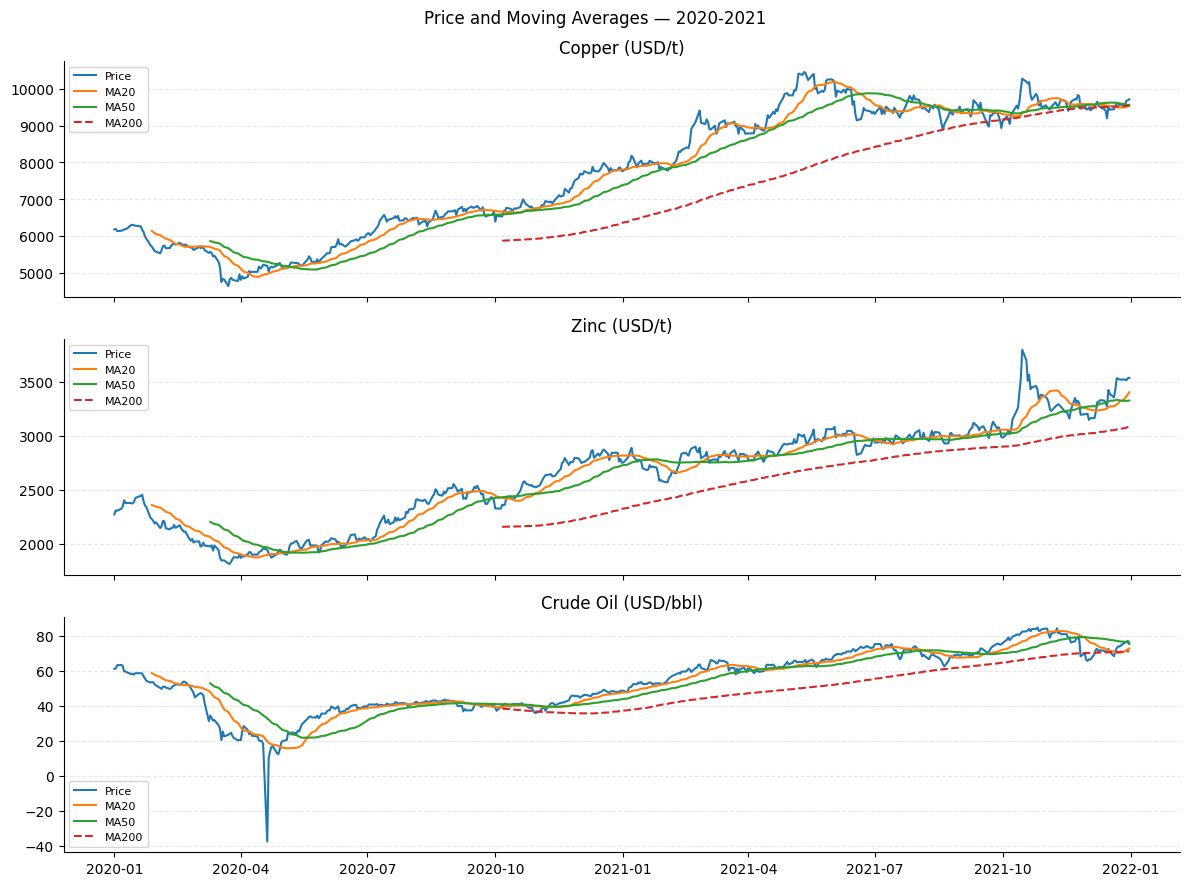

In [12]:
LABELS = {
    "copper": "Copper (USD/t)",
    "zinc": "Zinc (USD/t)",
    "crude_oil": "Crude Oil (USD/bbl)",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

for ax, commodity in zip(axes, COMMODITIES):
    sub = df_indicators[df_indicators["commodity"] == commodity]
    ax.plot(sub["date"], sub["price"], label="Price")
    ax.plot(sub["date"], sub["ma_fast"], label="MA20")
    ax.plot(sub["date"], sub["ma_medium"], label="MA50")
    ax.plot(sub["date"], sub["ma_slow"], linestyle="--", label="MA200")
    ax.set_title(LABELS[commodity])
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.suptitle("Price and Moving Averages — 2020-2021", fontsize=12)
fig.tight_layout()
plt.show()

## 4. Logging Decorator

The `insert_indicators` function is wrapped with a `@log_insert` decorator. A decorator in Python is a function that wraps another function; it runs its own logic before and after the wrapped function without modifying the function itself.

This decorator records:
- The function name
- Start time
- End time
- Execution duration
- Number of rows processed

This keeps the insert function clean and focused on inserting data, while the decorator handles observability separately.

In [13]:
print(inspect.getsource(log_insert))

def log_insert(func):
    """Log function name, start time, end time, duration, and rows inserted."""
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        logger.info(f"Starting {func.__name__} at {datetime.now().strftime('%H:%M:%S')}")
        rows = func(*args, **kwargs)
        duration = time.time() - start
        logger.info(
            f"Finished {func.__name__} | rows processed: {rows} | duration: {duration:.3f}s"
        )
        return rows
    return wrapper



## 5. Insert to Database

We pass the full indicators dataframe to `insert_indicators`. It formats dates as `YYYY-MM-DD`, adds the source column, and inserts using `executemany` with `INSERT OR IGNORE` and so re-running the pipeline is safe and will not create duplicate rows.

The decorator automatically logs the details when the function runs.

In [14]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)

rows = insert_indicators(df_indicators)
print(f"\nTotal rows passed to insert: {rows}")

18:33:15 | INFO | Starting insert_indicators at 18:33:15
18:33:15 | INFO | Finished insert_indicators | rows processed: 1569 | duration: 0.027s



Total rows passed to insert: 1569


## 6. Verify the Insert

Query the database to confirm the rows landed correctly.

In [21]:
from app.database import get_connection

conn = get_connection()

print("Rows in indicators table:")
for commodity in COMMODITIES:
    count = conn.execute(
        "SELECT COUNT(*) FROM indicators WHERE commodity = ?", (commodity,)
    ).fetchone()[0]
    print(f"{commodity:<12} {count} rows")

print("\nSample from database:")
df_check = pd.read_sql(
    "SELECT date, commodity, price, ma_fast, rsi FROM indicators ORDER BY commodity, date LIMIT 100",
    conn,
)

conn.close()
df_check

Rows in indicators table:
copper       523 rows
zinc         523 rows
crude_oil    523 rows

Sample from database:


,date,commodity,price,ma_fast,rsi
0,2020-01-01,copper,6174.0,NaN,NaN
1,2020-01-02,copper,6188.0,NaN,NaN
2,2020-01-03,copper,6129.5,NaN,NaN
3,2020-01-06,copper,6138.5,NaN,NaN
4,2020-01-07,copper,6149.0,NaN,NaN
...,...,...,...,...,...
95,2020-05-13,copper,5224.0,5187.000,53.990336
96,2020-05-14,copper,5202.0,5190.100,52.118835
97,2020-05-15,copper,5181.5,5188.625,50.366834
98,2020-05-18,copper,5317.5,5195.325,59.978574
